In [6]:
from sklearn.datasets import fetch_20newsgroups
CATEGORIES=['sci.space', 'rec.autos', 'talk.politics.misc']

data = fetch_20newsgroups(subset='train', categories=CATEGORIES)

documents = data.data
labels = data.target

print(len(documents))
print(documents[0])

1652
From: nickh@CS.CMU.EDU (Nick Haines)
Subject: Re: Vandalizing the sky.
In-Reply-To: todd@phad.la.locus.com's message of Wed, 21 Apr 93 16:28:00 GMT
Originator: nickh@SNOW.FOX.CS.CMU.EDU
Nntp-Posting-Host: snow.fox.cs.cmu.edu
Organization: School of Computer Science, Carnegie Mellon University
	<1993Apr21.162800.168967@locus.com>
Lines: 33

In article <1993Apr21.162800.168967@locus.com> todd@phad.la.locus.com (Todd Johnson) writes:

   As for advertising -- sure, why not?  A NASA friend and I spent one
   drunken night figuring out just exactly how much gold mylar we'd need
   to put the golden arches of a certain American fast food organization
   on the face of the Moon.  Fortunately, we sobered up in the morning.

Hmmm. It actually isn't all that much, is it? Like about 2 million
km^2 (if you think that sounds like a lot, it's only a few tens of m^2
per burger that said organization sold last year). You'd be best off
with a reflective substance that could be sprayed thinly by an

In [7]:
from sklearn.datasets import fetch_20newsgroups

print(fetch_20newsgroups().target_names)

['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


In [8]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression

In [9]:
CATEGORIES        = ['sci.space', 'rec.autos', 'talk.politics.misc']
COMPONENTS        = [50, 100, 200] #svd size
MAX_FEATURES      = 20000 #TF-id size
N_TOPICS_DISPLAY  = 5  #no of topic to display
TOP_N_TERMS       = 10 #no of words to display
RANDOM_STATE      = 42

In [10]:
print(f"\n{'='*60}")
print(f"  SVD for Document Topic Discovery (LSA)")
print(f"{'='*60}")
print(f"  Categories : {CATEGORIES}")
print(f"  Components : {COMPONENTS}")
print(f"  Max TF-IDF : {MAX_FEATURES} features")
print(f"{'='*60}\n")


  SVD for Document Topic Discovery (LSA)
  Categories : ['sci.space', 'rec.autos', 'talk.politics.misc']
  Components : [50, 100, 200]
  Max TF-IDF : 20000 features



In [11]:
newsgroups_train=fetch_20newsgroups(
    subset='train',
    categories=CATEGORIES ,
    remove=('headers','footer','quotes'),
    random_state=RANDOM_STATE
)

newsgroups_test=fetch_20newsgroups(
    subset='test',
    categories=CATEGORIES ,
    remove=('headers','footer','quotes'),
    random_state=RANDOM_STATE
)

X_raw_train=newsgroups_train.data
y_train=newsgroups_train.target
X_raw_test=newsgroups_test.data
y_test=newsgroups_test.target
target_names=newsgroups_train.target_names

print(f"   Train samples : {len(X_raw_train)}")
print(f"   Test samples  : {len(X_raw_test)}")
print(f"   Categories    : {target_names}")
print(f"   Class dist    : {dict(zip(target_names, np.bincount(y_train)))}\n")



   Train samples : 1652
   Test samples  : 1100
   Categories    : ['rec.autos', 'sci.space', 'talk.politics.misc']
   Class dist    : {'rec.autos': np.int64(594), 'sci.space': np.int64(593), 'talk.politics.misc': np.int64(465)}



In [12]:
tfidf=TfidfVectorizer(
    max_features=MAX_FEATURES,
    stop_words='english',
    min_df=3,
    max_df=0.90,
    ngram_range=(1,2),
    sublinear_tf=True
)

X_tfidf_train=tfidf.fit_transform(X_raw_train)
X_tfidf_test=tfidf.transform(X_raw_test)
feature_names=tfidf.get_feature_names_out()

sparsity=100*(1-X_tfidf_train.nnz/(X_tfidf_train.shape[0]*X_tfidf_train.shape[1]))

print(f"   TF-IDF shape (train) : {X_tfidf_train.shape}")
print(f"   TF-IDF shape (test)  : {X_tfidf_test.shape}")
print(f"   Vocabulary size      : {len(feature_names)}")
print(f"   Sparsity             : {sparsity:.2f}%\n")


   TF-IDF shape (train) : (1652, 12405)
   TF-IDF shape (test)  : (1100, 12405)
   Vocabulary size      : 12405
   Sparsity             : 99.37%



In [13]:
results_records = []
topic_outputs   = []
svd_models      = {}
reduced_data    = {}

print(f"{'='*60}")
print(f"TruncatedSVD (LSA) Results")
print(f"{'='*60}")

for n_components in COMPONENTS:
    print(f"\n>> Components = {n_components}")
    print(f"   {'-'*40}")

    svd        = TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)
    normalizer = Normalizer(copy=False)

    X_svd_train = svd.fit_transform(X_tfidf_train)
    X_svd_train = normalizer.fit_transform(X_svd_train)
    X_svd_test  = svd.transform(X_tfidf_test)
    X_svd_test  = normalizer.transform(X_svd_test)

    explained_var = svd.explained_variance_ratio_.sum()
    print(f"   Explained variance ratio : {explained_var:.4f} ({explained_var*100:.2f}%)")

    n_clusters     = len(target_names)
    km             = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=10, max_iter=300)
    cluster_labels = km.fit_predict(X_svd_train)
    sil_score      = silhouette_score(X_svd_train, cluster_labels, metric='cosine',
                                      sample_size=2000, random_state=RANDOM_STATE)
    print(f"   Silhouette score         : {sil_score:.4f}")

    clf    = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    clf.fit(X_svd_train, y_train)
    y_pred = clf.predict(X_svd_test)
    acc    = accuracy_score(y_test, y_pred)
    print(f"   Classification accuracy  : {acc:.4f} ({acc*100:.2f}%)")

    svd_models[n_components]   = svd
    reduced_data[n_components] = (X_svd_train, X_svd_test)

    results_records.append({
        'components':       n_components,
        'explained_var':    round(explained_var, 4),
        'silhouette_score': round(sil_score, 4),
        'accuracy':         round(acc, 4)
    })

    topic_block = [
        f"\n{'='*60}",
        f" LSA Topics — {n_components} Components",
        f"{'='*60}",
        f" Explained Var: {explained_var:.4f} | Silhouette: {sil_score:.4f} | Accuracy: {acc:.4f}\n"
    ]

    print(f"\n   Top {TOP_N_TERMS} terms for first {N_TOPICS_DISPLAY} topics:")
    for topic_idx in range(min(N_TOPICS_DISPLAY, n_components)):
        top_indices = svd.components_[topic_idx].argsort()[:-TOP_N_TERMS - 1:-1]
        top_terms   = [feature_names[i] for i in top_indices]
        line        = f"   Topic {topic_idx+1:>2}: {', '.join(top_terms)}"
        print(line)
        topic_block.append(line.strip())

    topic_outputs.append('\n'.join(topic_block))

TruncatedSVD (LSA) Results

>> Components = 50
   ----------------------------------------
   Explained variance ratio : 0.1483 (14.83%)
   Silhouette score         : 0.0799
   Classification accuracy  : 0.8973 (89.73%)

   Top 10 terms for first 5 topics:
   Topic  1: just, like, don, people, car, think, know, edu, space, time
   Topic  2: henry, toronto, zoology, spencer toronto, edu utzoo, toronto zoology, utzoo henry, utzoo, henry zoo, zoo toronto
   Topic  3: __, ___, space, nasa, baalke, ___ __, _____, gov, nasa gov, __ __
   Topic  4: alaska, michael adams, jacked, just jacked, nsmca acad3, adams nsmca, edu high, alaska edu, acad3, acad3 alaska
   Topic  5: cramer, clayton, optilink, uunet, uunet pyramid, clayton cramer, pyramid, cramer opinions, optilink cramer, pyramid optilink

>> Components = 100
   ----------------------------------------
   Explained variance ratio : 0.2291 (22.91%)
   Silhouette score         : 0.0331
   Classification accuracy  : 0.8991 (89.91%)

   Top 

In [14]:
best_n = max(results_records, key=lambda r: r['accuracy'])['components']
X_best_train, X_best_test = reduced_data[best_n]

clf_best = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
clf_best.fit(X_best_train, y_train)
y_pred_best = clf_best.predict(X_best_test)

print(f"\n\n>> Detailed Classification Report (best: n_components={best_n})")
print('='*60)
print(classification_report(y_test, y_pred_best, target_names=target_names))




>> Detailed Classification Report (best: n_components=200)
                    precision    recall  f1-score   support

         rec.autos       0.92      0.92      0.92       396
         sci.space       0.90      0.90      0.90       394
talk.politics.misc       0.88      0.88      0.88       310

          accuracy                           0.90      1100
         macro avg       0.90      0.90      0.90      1100
      weighted avg       0.90      0.90      0.90      1100



In [15]:
results_df = pd.DataFrame(results_records)
results_df.to_csv('svd_results.csv', index=False)
print("\n>> Results Summary:")
print(results_df.to_string(index=False))
print("\n   Saved: svd_results.csv")

# lsa_topic_terms.txt
header = [
    "LSA Topic Terms — SVD for Document Topic Discovery",
    f"Categories        : {CATEGORIES}",
    f"Components tested : {COMPONENTS}",
    f"Top {TOP_N_TERMS} terms shown for {N_TOPICS_DISPLAY} topics each\n"
]
with open('lsa_topic_terms.txt', 'w') as f:
    f.write('\n'.join(header))
    f.write('\n'.join(topic_outputs))
    f.write('\n')
print("   Saved: lsa_topic_terms.txt")


>> Results Summary:
 components  explained_var  silhouette_score  accuracy
         50         0.1483            0.0799    0.8973
        100         0.2291            0.0331    0.8991
        200         0.3558            0.0177    0.9018

   Saved: svd_results.csv
   Saved: lsa_topic_terms.txt



>> Generating plots...


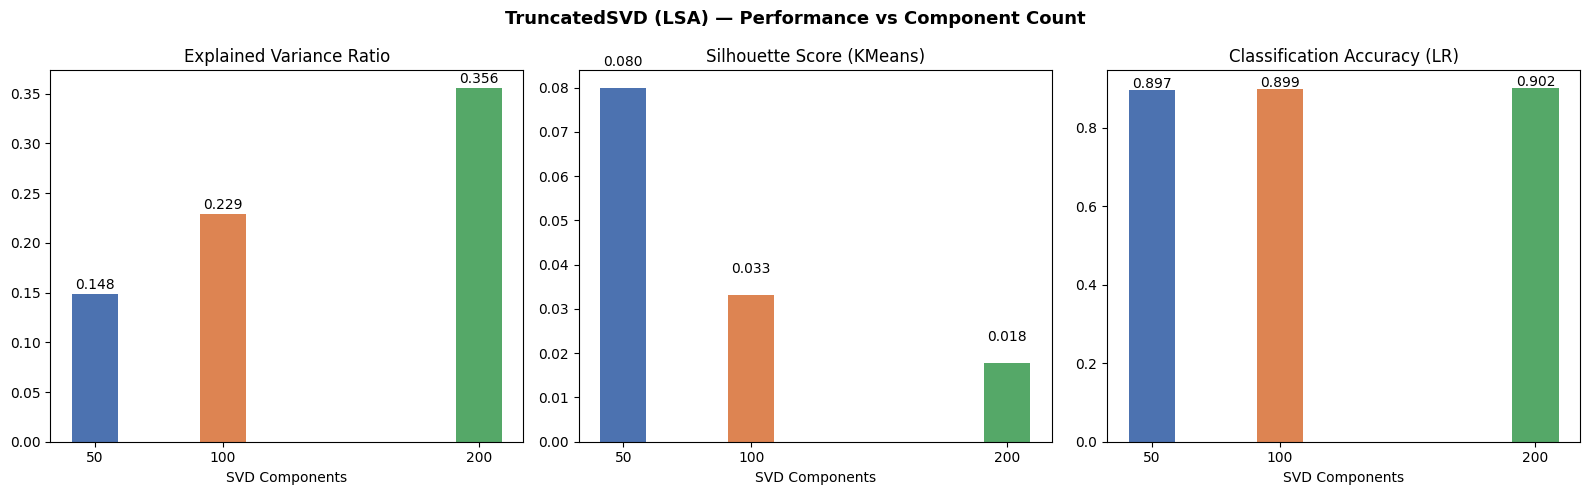

   Saved: svd_performance_comparison.png


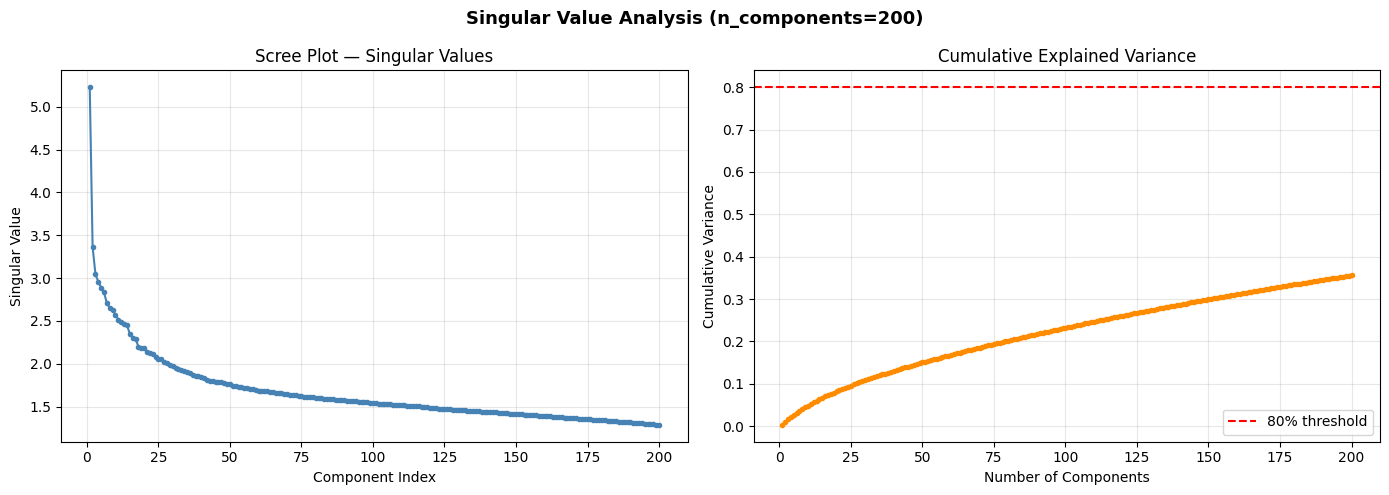

   Saved: svd_singular_values.png


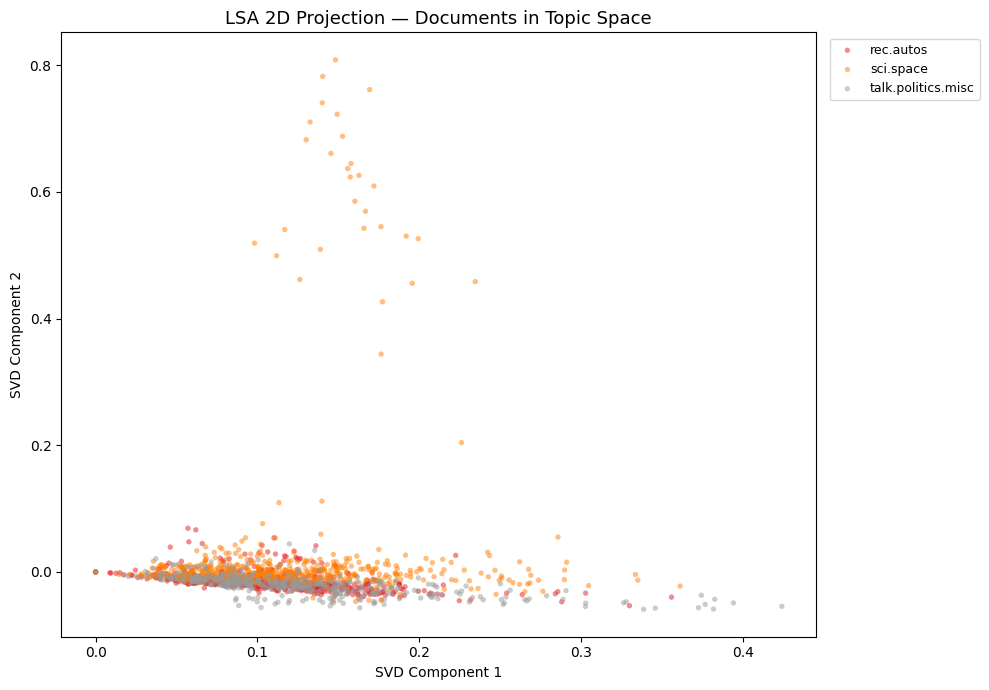

   Saved: svd_2d_projection.png


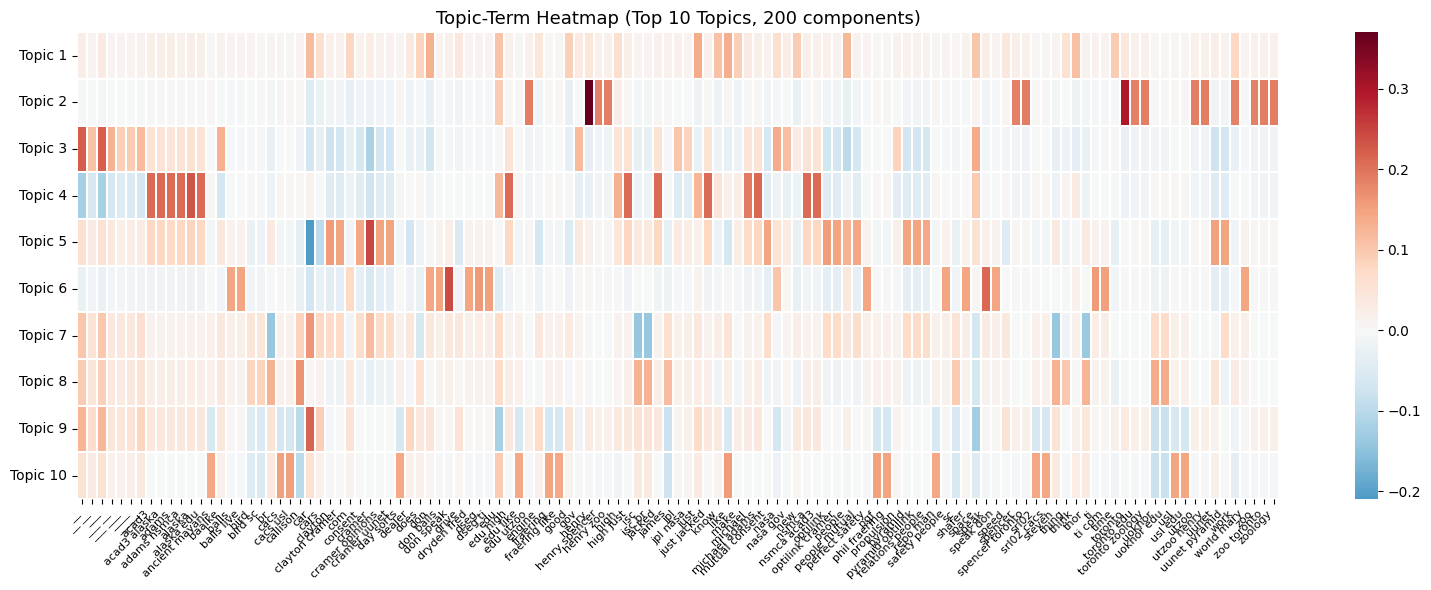

   Saved: svd_topic_term_heatmap.png


In [16]:

print("\n>> Generating plots...")

comp_vals = results_df['components'].tolist()
colors    = ['#4C72B0', '#DD8452', '#55A868']

# Plot 1 — Metrics bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('TruncatedSVD (LSA) — Performance vs Component Count', fontsize=13, fontweight='bold')

metrics = [
    ('explained_var',    'Explained Variance Ratio'),
    ('silhouette_score', 'Silhouette Score (KMeans)'),
    ('accuracy',         'Classification Accuracy (LR)')
]
for ax, (col, title) in zip(axes, metrics):
    vals = results_df[col].tolist()
    ax.bar(comp_vals, vals, color=colors, width=18)
    ax.set_title(title)
    ax.set_xlabel('SVD Components')
    ax.set_xticks(comp_vals)
    for i, v in enumerate(vals):
        ax.text(comp_vals[i], v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('svd_performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("   Saved: svd_performance_comparison.png")

# Plot 2 — Scree + Cumulative Variance
best_svd = svd_models[max(COMPONENTS)]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Singular Value Analysis (n_components={max(COMPONENTS)})', fontsize=13, fontweight='bold')

axes[0].plot(range(1, len(best_svd.singular_values_) + 1),
             best_svd.singular_values_, marker='o', markersize=3, color='steelblue')
axes[0].set_title('Scree Plot — Singular Values')
axes[0].set_xlabel('Component Index')
axes[0].set_ylabel('Singular Value')
axes[0].grid(True, alpha=0.3)

cumvar = np.cumsum(best_svd.explained_variance_ratio_)
axes[1].plot(range(1, len(cumvar) + 1), cumvar, marker='o', markersize=3, color='darkorange')
axes[1].axhline(y=0.80, color='red', linestyle='--', label='80% threshold')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('svd_singular_values.png', dpi=150, bbox_inches='tight')
plt.show()
print("   Saved: svd_singular_values.png")

# Plot 3 — 2D Document Scatter
X_2d    = svd_models[max(COMPONENTS)].transform(X_tfidf_train)[:, :2]
palette = plt.cm.Set1(np.linspace(0, 0.9, len(target_names)))

plt.figure(figsize=(10, 7))
for cls_idx, (cls_name, color) in enumerate(zip(target_names, palette)):
    mask = y_train == cls_idx
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], c=[color],
                label=cls_name, alpha=0.5, s=15, edgecolors='none')
plt.title('LSA 2D Projection — Documents in Topic Space', fontsize=13)
plt.xlabel('SVD Component 1')
plt.ylabel('SVD Component 2')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('svd_2d_projection.png', dpi=150, bbox_inches='tight')
plt.show()
print("   Saved: svd_2d_projection.png")

# Plot 4 — Topic-Term Heatmap
n_show_topics = min(10, min(COMPONENTS))
n_show_terms  = 15
all_top_idx   = set()
for i in range(n_show_topics):
    all_top_idx.update(best_svd.components_[i].argsort()[:-n_show_terms - 1:-1])

top_idx      = sorted(list(all_top_idx))
top_terms    = [feature_names[i] for i in top_idx]
heatmap_data = best_svd.components_[:n_show_topics, :][:, top_idx]

plt.figure(figsize=(16, 6))
sns.heatmap(heatmap_data,
            xticklabels=top_terms,
            yticklabels=[f'Topic {i+1}' for i in range(n_show_topics)],
            cmap='RdBu_r', center=0, linewidths=0.3)
plt.title(f'Topic-Term Heatmap (Top {n_show_topics} Topics, {max(COMPONENTS)} components)', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('svd_topic_term_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("   Saved: svd_topic_term_heatmap.png")

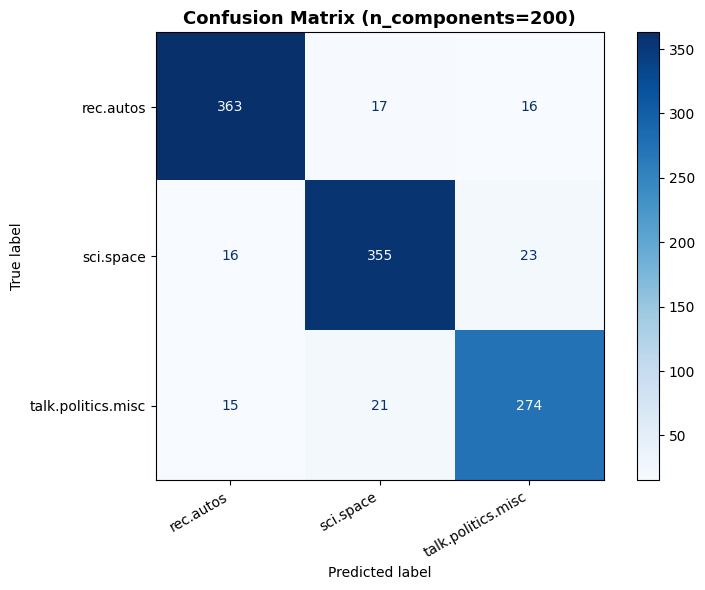


Classification Report (n_components=200)
                    precision    recall  f1-score   support

         rec.autos       0.92      0.92      0.92       396
         sci.space       0.90      0.90      0.90       394
talk.politics.misc       0.88      0.88      0.88       310

          accuracy                           0.90      1100
         macro avg       0.90      0.90      0.90      1100
      weighted avg       0.90      0.90      0.90      1100



In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Use the best model
best_n = max(results_records, key=lambda r: r['accuracy'])['components']
X_best_train, X_best_test = reduced_data[best_n]

clf_best = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
clf_best.fit(X_best_train, y_train)
y_pred_best = clf_best.predict(X_best_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap='Blues', ax=plt.gca())
plt.title(f'Confusion Matrix (n_components={best_n})', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print classification report
print(f"\nClassification Report (n_components={best_n})")
print('='*60)
print(classification_report(y_test, y_pred_best, target_names=target_names))


In [18]:


def predict_my_text(my_text):
    my_tfidf = tfidf.transform([my_text])

    best_n   = max(results_records, key=lambda r: r['accuracy'])['components']
    best_svd = svd_models[best_n]
    my_svd   = best_svd.transform(my_tfidf)
    my_svd   = Normalizer().fit_transform(my_svd)

    prediction     = clf_best.predict(my_svd)
    probabilities  = clf_best.predict_proba(my_svd)[0]

    print(f"\nInput Text  : {my_text}")
    print(f"Predicted   : {target_names[prediction[0]]}")
    print(f"\nConfidence scores:")
    for name, prob in zip(target_names, probabilities):
        bar = '█' * int(prob * 40)
        print(f"  {name:<25} {prob:.4f}  {bar}")

predict_my_text("NASA launched a new rocket to the moon today")

predict_my_text("The new Ferrari has an amazing turbocharged engine")

predict_my_text("The president signed a new law in congress today")



Input Text  : NASA launched a new rocket to the moon today
Predicted   : sci.space

Confidence scores:
  rec.autos                 0.0038  
  sci.space                 0.9912  ███████████████████████████████████████
  talk.politics.misc        0.0051  

Input Text  : The new Ferrari has an amazing turbocharged engine
Predicted   : rec.autos

Confidence scores:
  rec.autos                 0.9631  ██████████████████████████████████████
  sci.space                 0.0129  
  talk.politics.misc        0.0240  

Input Text  : The president signed a new law in congress today
Predicted   : talk.politics.misc

Confidence scores:
  rec.autos                 0.0118  
  sci.space                 0.0078  
  talk.politics.misc        0.9804  ███████████████████████████████████████
